# WhatsApp Code-Switching Analysis
### Simple, honest EN-PT mixing analysis — no model training

1. Parses WhatsApp `.txt` — real senders only, no system/group noise
2. Labels every word EN · PT · UNSURE using `lingua` at >=90% confidence
3. Abbreviations (mto, pq, vc, hj...) treated as UNSURE
4. Per-sender: who code-switches most?
5. Per-language: do words land in function or content slots?
6. Syntax matrix: PT-grammar+EN fillers / mixed / EN-grammar+PT fillers
7. Embedding space: XLM-RoBERTa (frozen) maps messages + pure EN/PT refs into 2-D


## 1 · Install

In [1]:
%%capture
!pip install lingua-language-detector transformers torch \
             matplotlib seaborn pandas numpy wordcloud scikit-learn tqdm spacy
!python -m spacy download en_core_web_sm
!python -m spacy download pt_core_news_sm
print('done')


## 2 · Imports & constants

In [2]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import torch
from transformers import AutoTokenizer, AutoModel
from lingua import Language, LanguageDetectorBuilder
warnings.filterwarnings('ignore')
tqdm.pandas()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

C = dict(en='#3B82F6', pt='#10B981', mixed='#F59E0B',
         fn='#8B5CF6', ct='#EF4444', grey='#94A3B8')
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110,
})

# Abbreviations and slang and names -> always UNSURE
UNSURE = {
    'mto','mt','pq','bc','blz','gnt','hj','tmb','vc','tb','tbm','tmj',
    'slk','vlw','obg','pfv','msm','qdo','qnd','amh','dms','sdds','sdd',
    'bjs','bjo','flw','add','msg','msgs','vdd','vd','oq','oqe','aq','aki',
    'vo','vcs','nd','nda','td','tdo','tds','nn',
    'lol','omg','wtf','ngl','imo','idk','irl','afk','brb','tbh','fyi',
    'pls','plz','thx','ty','np','ok','oke',
    'kkk','kkkk','kkkkk','kk','rsrs','rs','haha','hahaha','hahah',
    'huhu','hihi','eheh','lmao','lmfao',
    'ai','ah','oh','oi','ei','ui','xi','oxe','eita','uai','bah',
    'esther', 'bruna', 'gisele', 'Esther', 'Bruna', 'Gisele',
    'Padrão', 'Fretta', 'Barros', 'Siqueira', 'Marinho', 'Costa', 'padrão',
    'fretta', 'barros','siqueira', 'marinho', 'costa', 'qlqr', 'bbs', 'bb', 'poise'
}

EN_FUNCTION = {
    'the','a','an','is','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','could','should',
    'may','might','shall','can','this','that','these','those',
    'i','you','he','she','it','we','they','me','him','her','us','them',
    'my','your','his','its','our','their','and','but','or','so','yet',
    'in','on','at','to','for','of','with','by','from','about','into',
    'not','no','if','then','when','where','how','what','who','which','just',
}
PT_FUNCTION = {
    'o','a','os','as','um','uma','uns','umas',
    'estar','ter','haver','ser',
    'eu','tu','ele','ela','nos','voces','eles','elas',
    'me','te','se','lhe','lhes',
    'meu','minha','seu','sua','nosso','nossa',
    'e','mas','ou','que','quando','onde','como','quem','quanto',
    'de','do','da','dos','das','em','no','na',
    'para','por','com','sem','sobre','entre','ate','apos','pra','pro',
    'nao','nem','sim','ja','so','mais','menos','muito','pouco',
    'ao','aos','isso','esse','essa','este','esta','aqui','la',
}
print('setup complete')


Device: cpu
setup complete


## 3 · Load & parse WhatsApp chat

Supports Android (`DD/MM/YYYY, HH:MM - Sender: msg`) and iOS (`[DD/MM/YYYY, HH:MM:SS] Sender: msg`) formats.

**Sender filtering:** field > 40 chars, long digit runs, or system keywords like 'added'/'created'/'left' are discarded automatically.


In [3]:
DEMO_CHAT = """
01/12/2024, 09:00 - Ana: Oi! Did you see the email que o chefe mandou?\n01/12/2024, 09:01 - Joao: Yes! Que absurdo ne? I can't believe ele cancelou tudo\n01/12/2024, 09:02 - Ana: I know. Tava tao animada pra essa meeting\n01/12/2024, 09:03 - Joao: Me too cara. Anyway vamos reschedule pra semana que vem\n01/12/2024, 09:04 - Ana: Can you send me the link do documento?\n01/12/2024, 09:05 - Joao: Claro! I will share it agora mesmo\n01/12/2024, 09:06 - Ana: Obrigada! By the way voce viu o report que a Maria fez?\n01/12/2024, 09:07 - Joao: Vi sim muito bom. She nailed it na apresentacao\n01/12/2024, 09:08 - Ana: Totally. Ela e muito boa nisso\n01/12/2024, 09:09 - Joao: Bora grab um cafe depois da call?\n01/12/2024, 09:10 - Ana: Sim! Aquele place novo na rua de baixo?\n01/12/2024, 09:11 - Joao: Exatamente esse. They have amazing pasteis apparently\n01/12/2024, 09:12 - Ana: Serio?? I need to try that immediately\n01/12/2024, 09:13 - Joao: Perfeito. See you at three entao\n01/12/2024, 09:14 - Ana: Combinado! Don't be late\n01/12/2024, 09:15 - Joao: Never. Vai ficar tudo certo don't worry\n01/12/2024, 09:16 - Ana: Mas serio thanks for handling that situation\n01/12/2024, 09:17 - Joao: Claro amiga anytime. E pra isso que a gente esta aqui\n01/12/2024, 09:18 - Ana: Good morning a todos que comeco de dia\n01/12/2024, 09:19 - Joao: Right? Totally insane. Mas vamos la\n02/01/2024, 14:22 - Ana: Cara I totally forgot de mandar o email pra ela hoje\n02/01/2024, 14:23 - Joao: Seriously? You need to do that agora\n02/01/2024, 14:24 - Ana: Ja estou mandando. Sorry pelo delay\n02/01/2024, 14:25 - Joao: By the way a reuniao de amanha foi cancelada\n02/01/2024, 14:26 - Ana: Nossa really? Why?\n02/01/2024, 14:27 - Joao: Nao sei. They just sent an email agora\n02/01/2024, 14:28 - Ana: Que baguncinha. Anyway let me finish this first\n02/01/2024, 14:29 - Joao: Take your time\n15/02/2024, 20:11 - Ana: Hoje foi pesado. I am exhausted\n15/02/2024, 20:12 - Joao: Tambem. That meeting was way too long\n15/02/2024, 20:13 - Ana: Totally. Precisamos de um break\n15/02/2024, 20:14 - Joao: Agreed. Vamos sair no weekend?\n15/02/2024, 20:15 - Ana: Yes! Aquele bar novo?\n15/02/2024, 20:16 - Joao: Perfeito. I will check the hours\n15/02/2024, 20:17 - Ana: Otimo. See you entao\n03/03/2024, 11:05 - Ana: Just checking in tudo bem?\n03/03/2024, 11:06 - Joao: Tudo bem! Busy but good. E voce?\n03/03/2024, 11:07 - Ana: Mesma coisa. I have so much to do hoje\n03/03/2024, 11:08 - Joao: Eu tambem. Let's catch up depois\n03/03/2024, 11:09 - Ana: Combinado. Talk later entao
"""

NOISE_RE = re.compile(
    r'end.to.end encrypted|<media omitted>|image omitted|video omitted|'
    r'audio omitted|sticker omitted|document omitted|missed voice call|'
    r'missed video call|changed the subject| added | left$|'
    r'created group|removed |pinned a message|security code changed',
    re.IGNORECASE,
)

LINE_PATTERNS = [
    re.compile(
        r'^(\d{1,2}[\/\.\-]\d{1,2}[\/\.\-]\d{2,4})'
        r',\s*([\d:]+(?:\s?[AP]M)?)\s*-\s*([^:]{1,40}):\s*(.+)$'
    ),
    re.compile(
        r'^\[(\d{1,2}[\/\.\-]\d{1,2}[\/\.\-]\d{2,4})'
        r',\s*([\d:]+(?:\s?[AP]M)?)\]\s*([^:]{1,40}):\s*(.+)$'
    ),
]

SENDER_NOISE = ['created','added','left','removed','changed',
                'group','security','encrypted','joined','call']

# Exact names to block entirely (group name etc.)
BLOCKED_SENDERS = {'submete demais'}

def is_valid_sender(name):
    name = name.strip()
    # Strip invisible Unicode control characters (LTR mark, ZWS, etc.)
    name_clean = re.sub(r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]', '', name)
    if name_clean.lower() in BLOCKED_SENDERS: return False
    if len(name_clean) > 40: return False
    if re.search(r'\d{7,}', name_clean): return False
    if any(k in name_clean.lower() for k in SENDER_NOISE): return False
    return True

def parse_whatsapp(raw_text):
    messages, current = [], None
    for line in raw_text.strip().splitlines():
        matched = False
        for pat in LINE_PATTERNS:
            m = pat.match(line.strip())
            if m:
                if current: messages.append(current)
                date, time, sender, msg = m.groups()
                current = None
                if not is_valid_sender(sender): matched = True; break
                if NOISE_RE.search(msg):        matched = True; break
                current = {'date': date, 'time': time,
                           'sender': sender.strip(), 'message': msg.strip()}
                matched = True; break
        if not matched and current:
            current['message'] += ' ' + line.strip()
    if current: messages.append(current)
    df = pd.DataFrame(messages)
    df = df[df['message'].str.len() > 3].reset_index(drop=True)
    return df

CHAT_PATH = None
try:
    from google.colab import files
    print('Upload your WhatsApp _chat.txt ...')
    uploaded  = files.upload()
    CHAT_PATH = list(uploaded.keys())[0]
except Exception:
    pass

if CHAT_PATH:
    with open(CHAT_PATH, encoding='utf-8') as f:
        df = parse_whatsapp(f.read())
    print('Loaded from file')
else:
    df = parse_whatsapp(DEMO_CHAT)
    print('DEMO MODE - upload your own chat for real results')

# ── Merge "Você" into your real sender name ───────────────────────────────────
YOUR_NAME = "Esther Padrão"

# Strip invisible Unicode chars from all sender names before merging
df["sender"] = df["sender"].str.replace(
    r'[\u200e\u200f\u200b\u202a-\u202e\ufeff]', '', regex=True
).str.strip()

df["sender"] = df["sender"].replace({"Você": YOUR_NAME, "Voce": YOUR_NAME})

print(f'{len(df)} messages, {df["sender"].nunique()} senders')
print(df['sender'].value_counts().to_string())


Upload your WhatsApp _chat.txt ...


Saving _chat.txt to _chat (6).txt
Loaded from file
9727 messages, 3 senders
sender
Bruna            3634
Gisele           3212
Esther Padrão    2881


## 4 · Label every word: EN · PT · UNSURE

Rules in order:
1. In abbreviation list → **UNSURE**
2. Shorter than 3 chars → **UNSURE**
3. `lingua` >= 90% confidence EN → **EN**
4. `lingua` >= 90% confidence PT → **PT**
5. Anything else → **UNSURE** (ignored in all analyses)

No model training. No train/val split. `lingua` is a statistical detector — we use its confidence score as a simple threshold filter.


In [4]:
detector = (
    LanguageDetectorBuilder
    .from_languages(Language.ENGLISH, Language.PORTUGUESE)
    .with_minimum_relative_distance(0.10)
    .build()
)
CONFIDENCE_THRESHOLD = 0.80

TOKEN_RE = re.compile(
    r'[a-zA-ZáàãâäéèêëíìîïóòõôöúùûüçñÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇÑ]'
    r'[a-zA-ZáàãâäéèêëíìîïóòõôöúùûüçñÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇÑ\'\-]*',
    re.UNICODE,
)

def label_words(message):
    results = []
    for word in TOKEN_RE.findall(message):
        w  = word.strip("'-")
        wl = w.lower()
        if wl in UNSURE or len(wl) < 3:
            results.append((word, 'unsure')); continue
        scores = detector.compute_language_confidence_values(w)
        if not scores:
            results.append((word, 'unsure')); continue
        best = scores[0]
        if best.value >= CONFIDENCE_THRESHOLD:
            label = 'en' if best.language == Language.ENGLISH else 'pt'
        else:
            label = 'unsure'
        results.append((word, label))
    return results

print('Labelling words — may take ~1 min on large chats ...')
df['word_labels'] = df['message'].progress_apply(label_words)

df['n_en']   = df['word_labels'].apply(lambda ws: sum(1 for _,l in ws if l=='en'))
df['n_pt']   = df['word_labels'].apply(lambda ws: sum(1 for _,l in ws if l=='pt'))
df['n_sure'] = df['n_en'] + df['n_pt']
df['en_ratio'] = df.apply(lambda r: r['n_en']/r['n_sure'] if r['n_sure'] else float('nan'), axis=1)
df['pt_ratio'] = df.apply(lambda r: r['n_pt']/r['n_sure'] if r['n_sure'] else float('nan'), axis=1)
df['is_mixed'] = (
    (df['n_en'] > 0) & (df['n_pt'] > 0) &
    (df[['en_ratio','pt_ratio']].min(axis=1) >= 0.15) &
    (df['n_sure'] >= 3)
)
print(f'{df["n_sure"].gt(0).sum()} messages with >=1 sure word')
print(f'{df["is_mixed"].sum()} classified as mixed-language')


Labelling words — may take ~1 min on large chats ...


  0%|          | 0/9727 [00:00<?, ?it/s]

8626 messages with >=1 sure word
777 classified as mixed-language


## 5 · Per-sender — who code-switches most?

In [5]:
rows = []
for sender, grp in df.groupby('sender'):
    total_sure = grp['n_sure'].sum()
    if total_sure == 0: continue
    rows.append({
        'sender':    sender,
        'messages':  len(grp),
        'sure_words': total_sure,
        'en_pct':    grp['n_en'].sum() / total_sure * 100,
        'pt_pct':    grp['n_pt'].sum() / total_sure * 100,
        'mixed_pct': grp['is_mixed'].mean() * 100,
    })
df_snd = pd.DataFrame(rows).sort_values('mixed_pct', ascending=False)
display(df_snd.round(1))


,sender,messages,sure_words,en_pct,pt_pct,mixed_pct
0,Bruna,3634,10722,8.7,91.3,10.7
2,Gisele,3212,11341,24.0,76.0,6.5
1,Esther Padrão,2881,6493,14.0,86.0,6.2


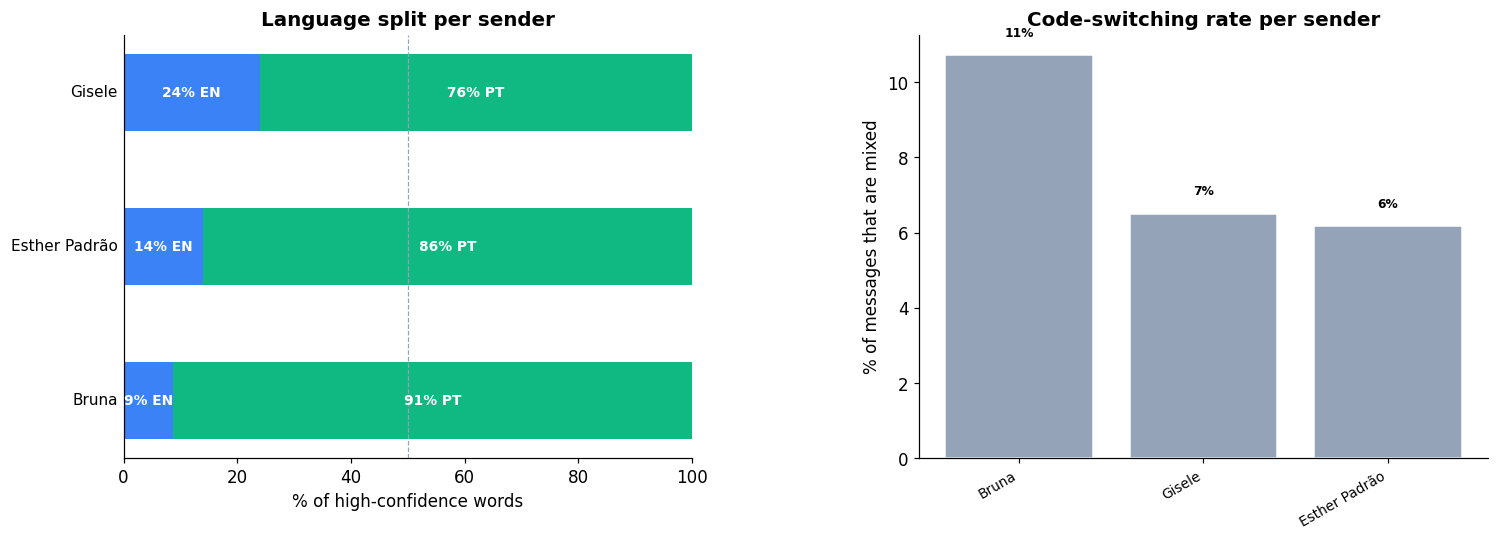

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("white")
fig.subplots_adjust(wspace=0.4)

# ── Plot 1: Language split ─────────────────────────────────────────────────────
ax1 = axes[0]
srt  = df_snd.sort_values("en_pct")
y    = np.arange(len(srt))

ax1.barh(y, srt["en_pct"].values, color=C["en"], height=0.5)
ax1.barh(y, srt["pt_pct"].values, left=srt["en_pct"].values,
         color=C["pt"], height=0.5)

# Labels inside the bars instead of on the y-axis
for i, (en, pt, name) in enumerate(zip(srt["en_pct"].values,
                                        srt["pt_pct"].values,
                                        srt["sender"].values)):
    ax1.text(en/2, i, f"{en:.0f}% EN",
             ha="center", va="center", fontsize=9,
             color="white", fontweight="bold")
    ax1.text(en + pt/2, i, f"{pt:.0f}% PT",
             ha="center", va="center", fontsize=9,
             color="white", fontweight="bold")
    ax1.text(-1, i, name,
             ha="right", va="center", fontsize=10)

ax1.set_yticks([])
ax1.set_xlim(0, 100)
ax1.set_xlabel("% of high-confidence words")
ax1.axvline(50, color=C["grey"], linewidth=0.8, linestyle="--")
ax1.set_title("Language split per sender", fontweight="bold")

# ── Plot 2: Mixing rate ────────────────────────────────────────────────────────
ax2 = axes[1]
srt2 = df_snd.sort_values("mixed_pct", ascending=False)
cols = [C["mixed"] if p > 25 else C["grey"] for p in srt2["mixed_pct"]]
bars = ax2.bar(srt2["sender"], srt2["mixed_pct"], color=cols, edgecolor="white")
for bar, v in zip(bars, srt2["mixed_pct"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{v:.0f}%", ha="center", fontsize=8, fontweight="bold")
ax2.set_ylabel("% of messages that are mixed")
ax2.set_title("Code-switching rate per sender", fontweight="bold")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=9)

plt.savefig("fig_per_sender.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 6 · What grammatical role do English words play?

For each word we already know the language (lingua, ≥90% confidence).
spaCy then tells us the grammatical role — in context, not from a hardcoded list.

EN words are passed through the English spaCy model, PT words through
the Portuguese model, and each token is classified as:

- **Content**: NOUN, VERB, ADJ, ADV, PROPN — meaning-bearing words
- **Function**: DET, ADP, AUX, CCONJ, SCONJ, PRON, PART — grammatical words
- **Other**: interjections, punctuation, numerals

**Plot 1 — POS heatmap**  
Rows = senders, columns = POS tags, values = % of that sender's
EN words in each tag. Shows whether EN words are mostly nouns/verbs
(content insertions) or determiners/prepositions (structural influence).

**Plot 2 — matrix language**  
For each mixed message: whichever language supplies more function words
is the matrix language (Myers-Scotton MLF model). Bar chart per sender
showing PT-matrix / balanced / EN-matrix across their mixed messages.


In [15]:
import spacy

nlp_en = spacy.load("en_core_web_sm")
nlp_pt = spacy.load("pt_core_news_sm")

CONTENT_POS  = {"NOUN", "VERB", "ADJ", "ADV", "PROPN"}
FUNCTION_POS = {"DET", "ADP", "AUX", "CCONJ", "SCONJ", "PRON", "PART"}

print("✅ spaCy models loaded")

✅ spaCy models loaded


In [16]:
def tag_message(row):
    en_words = [w for w, l in row["word_labels"] if l == "en"]
    pt_words = [w for w, l in row["word_labels"] if l == "pt"]

    en_tags = {tok.text.lower(): tok.pos_
               for tok in nlp_en(" ".join(en_words))} if en_words else {}
    pt_tags = {tok.text.lower(): tok.pos_
               for tok in nlp_pt(" ".join(pt_words))} if pt_words else {}

    result = []
    for word, lang in row["word_labels"]:
        if lang == "unsure":
            continue
        tags = en_tags if lang == "en" else pt_tags
        pos  = tags.get(word.lower(), "X")
        slot = ("content"  if pos in CONTENT_POS  else
                "function" if pos in FUNCTION_POS else "other")
        result.append((word, lang, pos, slot))  # pos=NOUN, slot=content
    return result

print("⏳ Re-tagging …")
df["pos_labels"] = df.progress_apply(tag_message, axis=1)
print("✅ done")

# Quick sanity check — should now show e.g. word='help' pos=VERB slot=content
sample = [(r["sender"], w, pos, slot)
          for _, r in df.iterrows()
          for w, lang, pos, slot in r["pos_labels"]
          if lang == "en"][:10]
for s, w, pos, slot in sample:
    print(f"  {s:20s}  '{w}'  pos={pos}  slot={slot}")

⏳ Re-tagging …


  0%|          | 0/9727 [00:00<?, ?it/s]

✅ done
  Bruna                 'help'  pos=VERB  slot=content
  Gisele                'Volkan'  pos=PROPN  slot=content
  Gisele                'alumni'  pos=NOUN  slot=content
  Gisele                'seoul'  pos=PROPN  slot=content
  Bruna                 'bucaneers'  pos=NOUN  slot=content
  Bruna                 'Finley'  pos=PROPN  slot=content
  Gisele                'queeere'  pos=NOUN  slot=content
  Gisele                'Shazil'  pos=PROPN  slot=content
  Bruna                 'internship'  pos=NOUN  slot=content
  Esther Padrão         'anne'  pos=PROPN  slot=content


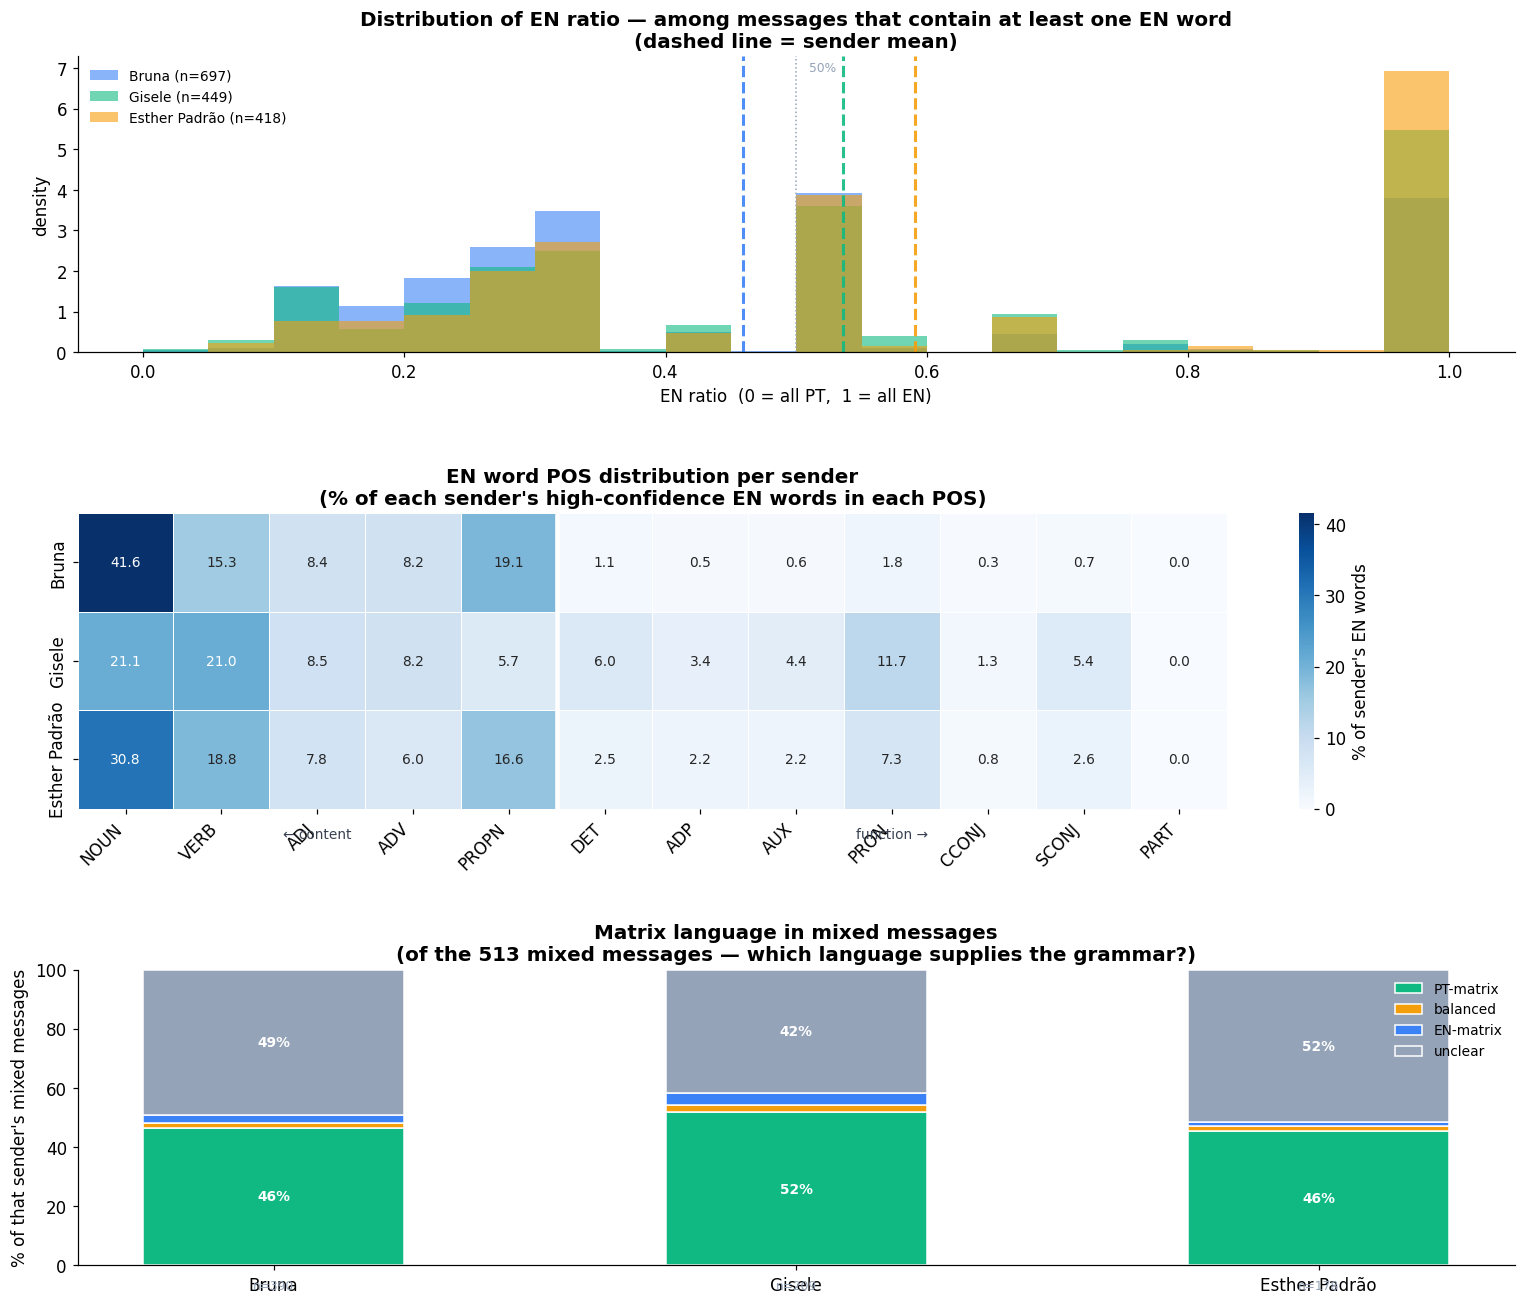

In [17]:
fig = plt.figure(figsize=(14, 12))
fig.patch.set_facecolor("white")

sender_list   = df_snd["sender"].tolist()
sender_colors = dict(zip(sender_list,
                         ["#3B82F6","#10B981","#F59E0B","#EF4444","#8B5CF6"]))

# ── Plot 1: EN ratio — only among messages that have EN words ─────────────────
ax1 = fig.add_subplot(3, 1, 1)

for sender in sender_list:
    vals = (df[(df["sender"] == sender) & (df["n_en"] > 0)]["en_ratio"]
            .dropna())
    if len(vals) == 0:
        continue
    ax1.hist(vals, bins=20, range=(0, 1), alpha=0.6,
             color=sender_colors[sender], label=f"{sender} (n={len(vals)})",
             density=True)
    ax1.axvline(vals.mean(), color=sender_colors[sender],
                linewidth=2, linestyle="--", alpha=0.9)

ax1.set_xlabel("EN ratio  (0 = all PT,  1 = all EN)")
ax1.set_ylabel("density")
ax1.set_title("Distribution of EN ratio — among messages that contain "
              "at least one EN word\n(dashed line = sender mean)",
              fontweight="bold")
ax1.legend(frameon=False, fontsize=9)
ax1.axvline(0.5, color=C["grey"], linewidth=1, linestyle=":")
ax1.text(0.51, ax1.get_ylim()[1]*0.95, "50%", fontsize=8, color=C["grey"])

# ── Plot 2: POS heatmap ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 1, 2)

POS_ORDER = ["NOUN","VERB","ADJ","ADV","PROPN",
             "DET","ADP","AUX","PRON","CCONJ","SCONJ","PART"]

heatmap_rows = []
for sender in sender_list:
    en_tokens = [(pos, slot)
                 for _, row in df[df["sender"]==sender].iterrows()
                 for w, lang, pos, slot in row["pos_labels"]
                 if lang == "en"]
    total_en  = len(en_tokens)
    counts    = Counter(pos for pos, _ in en_tokens)
    heatmap_rows.append({
        pos: counts.get(pos, 0) / max(1, total_en) * 100
        for pos in POS_ORDER
    })

df_heat = pd.DataFrame(heatmap_rows, index=sender_list)[POS_ORDER]

sns.heatmap(df_heat, ax=ax2, cmap="Blues", annot=True, fmt=".1f",
            linewidths=0.5, cbar_kws={"label": "% of sender's EN words"},
            annot_kws={"size": 9}, vmin=0)

ax2.axvline(5, color="white", linewidth=3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_ylabel("")
ax2.text(2.5, len(sender_list)+0.3, "← content", ha="center",
         fontsize=9, color="#374151")
ax2.text(8.5, len(sender_list)+0.3, "function →", ha="center",
         fontsize=9, color="#374151")
ax2.set_title("EN word POS distribution per sender\n"
              "(% of each sender's high-confidence EN words in each POS)",
              fontweight="bold")

# ── Plot 3: matrix language in mixed messages ──────────────────────────────────
ax3 = fig.add_subplot(3, 1, 3)

matrix_records = []
for _, row in df[df["is_mixed"]].iterrows():
    fn_en = sum(1 for w, lang, pos, slot in row["pos_labels"]
                if lang == "en" and slot == "function")
    fn_pt = sum(1 for w, lang, pos, slot in row["pos_labels"]
                if lang == "pt" and slot == "function")
    if fn_en == 0 and fn_pt == 0: matrix = "unclear"
    elif fn_pt > fn_en:           matrix = "PT-matrix"
    elif fn_en > fn_pt:           matrix = "EN-matrix"
    else:                         matrix = "balanced"
    matrix_records.append({"sender": row["sender"], "matrix": matrix})

df_matrix = pd.DataFrame(matrix_records)

order  = ["PT-matrix","balanced","EN-matrix","unclear"]
colors = [C["pt"], C["mixed"], C["en"], C["grey"]]
bottom = np.zeros(len(sender_list))

for cat, col in zip(order, colors):
    vals = [df_matrix[df_matrix["sender"]==s]["matrix"].eq(cat).sum() /
            max(1, len(df_matrix[df_matrix["sender"]==s])) * 100
            for s in sender_list]
    bars = ax3.bar(sender_list, vals, bottom=bottom,
                   color=col, label=cat, edgecolor="white", width=0.5)
    # Label each segment if big enough to read
    for bar, v, b in zip(bars, vals, bottom):
        if v > 5:
            ax3.text(bar.get_x()+bar.get_width()/2, b+v/2,
                     f"{v:.0f}%", ha="center", va="center",
                     fontsize=9, fontweight="bold", color="white")
    bottom += np.array(vals)

ax3.set_ylim(0, 100)
ax3.set_ylabel("% of that sender's mixed messages")
ax3.set_title("Matrix language in mixed messages\n"
              "(of the 513 mixed messages — which language supplies the grammar?)",
              fontweight="bold")
ax3.legend(frameon=False, fontsize=9, loc="upper right")
# Print raw counts below
for i, sender in enumerate(sender_list):
    n = len(df_matrix[df_matrix["sender"]==sender])
    ax3.text(i, -8, f"n={n}", ha="center", fontsize=8, color=C["grey"])

plt.tight_layout(h_pad=3)
plt.savefig("fig_language_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

## 7 · How much English is actually in this chat?

**EN ratio** = EN sure words / (EN + PT sure words), per message.

The data shows this is a Portuguese-dominant chat with occasional English
insertions — so rather than a histogram (which just shows one giant spike at 0)


**Plot — frequency vs intensity**  
- Frequency = % of messages that contain *any* EN word at all
- Intensity = mean EN ratio in those messages (how much EN when they do switch)
- Bubble size = number of mixed messages

These two axes separate *how often* someone code-switches from
*how much* they switch when they do.


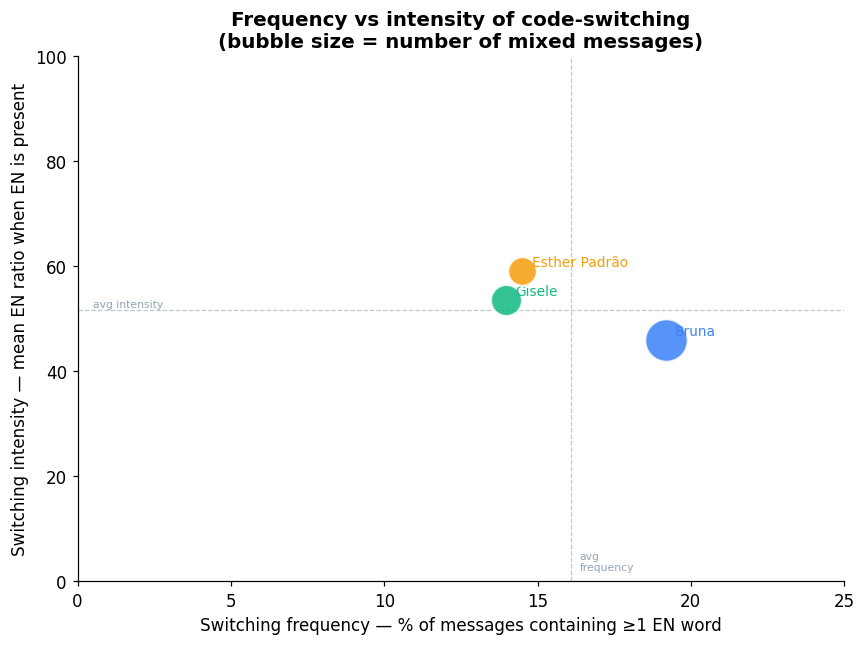

Sender                Freq (% msgs w/ EN)     Intensity (mean EN% | EN>0)   N mixed
-------------------------------------------------------------------------------------
Bruna                                 19.2%                        46.0%  390
Gisele                                14.0%                        53.6%  209
Esther Padrão                         14.5%                        59.1%  178


In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")

sender_list   = df_snd["sender"].tolist()
sender_colors = dict(zip(sender_list,
                         ["#3B82F6","#10B981","#F59E0B"]))

for sender in sender_list:
    grp       = df[df["sender"] == sender]
    frequency = grp["n_en"].gt(0).mean() * 100
    intensity = grp[grp["n_en"] > 0]["en_ratio"].mean() * 100
    n_mixed   = grp["is_mixed"].sum()

    ax.scatter(frequency, intensity,
               color=sender_colors[sender],
               s=n_mixed * 2,
               alpha=0.85, edgecolors="white", linewidth=1.5,
               zorder=3)
    ax.annotate(sender,
                xy=(frequency, intensity),
                xytext=(6, 3), textcoords="offset points",
                fontsize=9, color=sender_colors[sender])

all_freq = df["n_en"].gt(0).mean() * 100
all_int  = df[df["n_en"] > 0]["en_ratio"].mean() * 100
ax.axvline(all_freq, color=C["grey"], linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(all_int,  color=C["grey"], linewidth=0.8, linestyle="--", alpha=0.6)
ax.text(all_freq+0.3, 2, "avg\nfrequency", fontsize=7, color=C["grey"])
ax.text(0.5, all_int+0.5, "avg intensity", fontsize=7, color=C["grey"])

ax.set_xlabel("Switching frequency — % of messages containing ≥1 EN word")
ax.set_ylabel("Switching intensity — mean EN ratio when EN is present")
ax.set_title("Frequency vs intensity of code-switching\n"
             "(bubble size = number of mixed messages)",
             fontweight="bold")
ax.set_xlim(0, max(df_snd["mixed_pct"].max()*2, 25))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("fig_dotplot.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ── Table ─────────────────────────────────────────────────────────────────────
print(f"{'Sender':20s}  {'Freq (% msgs w/ EN)':22s}  {'Intensity (mean EN% | EN>0)':28s}  {'N mixed'}")
print("-" * 85)
for sender in sender_list:
    grp  = df[df["sender"] == sender]
    freq = grp["n_en"].gt(0).mean() * 100
    intn = grp[grp["n_en"] > 0]["en_ratio"].mean() * 100
    nm   = grp["is_mixed"].sum()
    print(f"{sender:20s}  {freq:>20.1f}%  {intn:>26.1f}%  {nm}")

## 8 · Word clouds — what vocabulary actually appears?

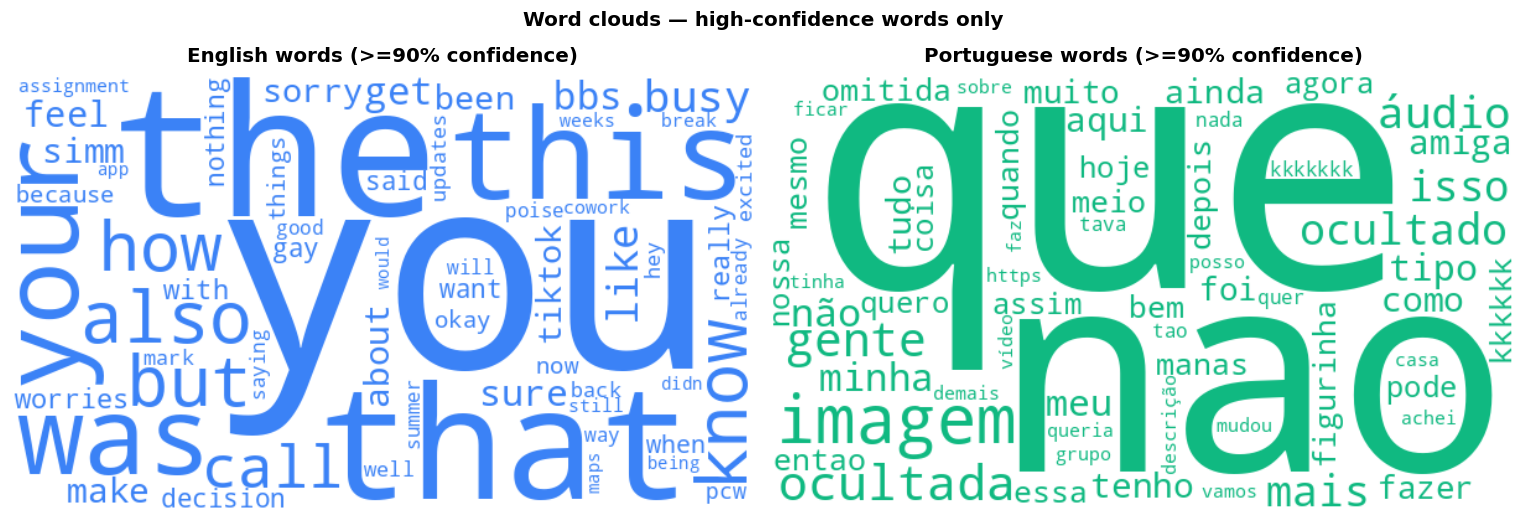

EN unique: 1424   PT unique: 3914


In [23]:
en_words = [w.lower() for _,row in df.iterrows() for w,l in row['word_labels'] if l=='en']
pt_words = [w.lower() for _,row in df.iterrows() for w,l in row['word_labels'] if l=='pt']

def make_wc(words, color, title, ax):
    if not words:
        ax.text(0.5,0.5,'No words',ha='center',va='center'); ax.axis('off'); return
    wc = WordCloud(width=600, height=350, background_color='white',
                   color_func=lambda *a,**k: color, max_words=60,
                   collocations=False, prefer_horizontal=0.85
                  ).generate_from_frequencies(Counter(words))
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(title, fontweight='bold', pad=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
make_wc(en_words, C['en'], 'English words (>=90% confidence)', axes[0])
make_wc(pt_words, C['pt'], 'Portuguese words (>=90% confidence)', axes[1])
fig.suptitle('Word clouds — high-confidence words only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_wordclouds.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'EN unique: {len(set(en_words))}   PT unique: {len(set(pt_words))}')


## 9 · Embedding space — where do your messages sit between EN and PT?

XLM-RoBERTa is run **frozen** (no training, no fine-tuning, no train/val split).
We mean-pool the last hidden state to get one vector per text.

We embed:
- All chat messages with at least one sure word
- 10 pure English reference sentences
- 10 pure Portuguese reference sentences

Then project everything into 2-D with PCA.
Messages near the EN stars → English feel in embedding space.
Messages near PT stars → Portuguese feel. Mixed → somewhere in between.


In [24]:
MODEL_NAME = 'xlm-roberta-base'
print(f'Loading {MODEL_NAME} (frozen, no training) ...')
_tok = AutoTokenizer.from_pretrained(MODEL_NAME)
_mdl = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
_mdl.eval()
print('Model loaded')

def embed(texts, batch_size=16):
    all_vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc='embedding', leave=False):
        batch = texts[i:i+batch_size]
        enc   = _tok(batch, return_tensors='pt', padding=True,
                     truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad():
            out = _mdl(**enc)
        mask = enc['attention_mask'].unsqueeze(-1).float()
        vecs = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
        all_vecs.append(vecs.cpu().numpy())
    return np.vstack(all_vecs)


Loading xlm-roberta-base (frozen, no training) ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


In [25]:
REF_EN = [
    'I need to finish this report before the deadline.',
    'Can you send me the link to the document?',
    'The meeting was cancelled because of the weather.',
    'She is really good at presentations and public speaking.',
    "Let's grab a coffee after the call.",
    'I totally forgot to send that email today.',
    'That place has amazing food apparently.',
    'Thanks for handling that situation so well.',
    'I am exhausted after such a long day at work.',
    "Let's catch up later this week if you are free.",
]
REF_PT = [
    'Preciso terminar esse relatorio antes do prazo.',
    'Voce pode me mandar o link do documento?',
    'A reuniao foi cancelada por causa do tempo.',
    'Ela e muito boa em apresentacoes e falar em publico.',
    'Vamos tomar um cafe depois da ligacao.',
    'Esqueci completamente de mandar aquele email hoje.',
    'Aquele lugar tem uma comida incrivel aparentemente.',
    'Obrigado por lidar com essa situacao tao bem.',
    'Estou exausta depois de um dia tao longo de trabalho.',
    'Vamos nos encontrar mais tarde essa semana se voce puder.',
]

df_emb = df[df['n_sure'] > 0].copy().reset_index(drop=True)
msgs   = df_emb['message'].tolist()
print(f'Embedding {len(msgs)} chat messages + {len(REF_EN)+len(REF_PT)} reference sentences ...')
chat_vecs   = embed(msgs)
en_ref_vecs = embed(REF_EN)
pt_ref_vecs = embed(REF_PT)
print('Done')


Embedding 8626 chat messages + 20 reference sentences ...


embedding:   0%|          | 0/540 [00:00<?, ?it/s]

embedding:   0%|          | 0/1 [00:00<?, ?it/s]

embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Done


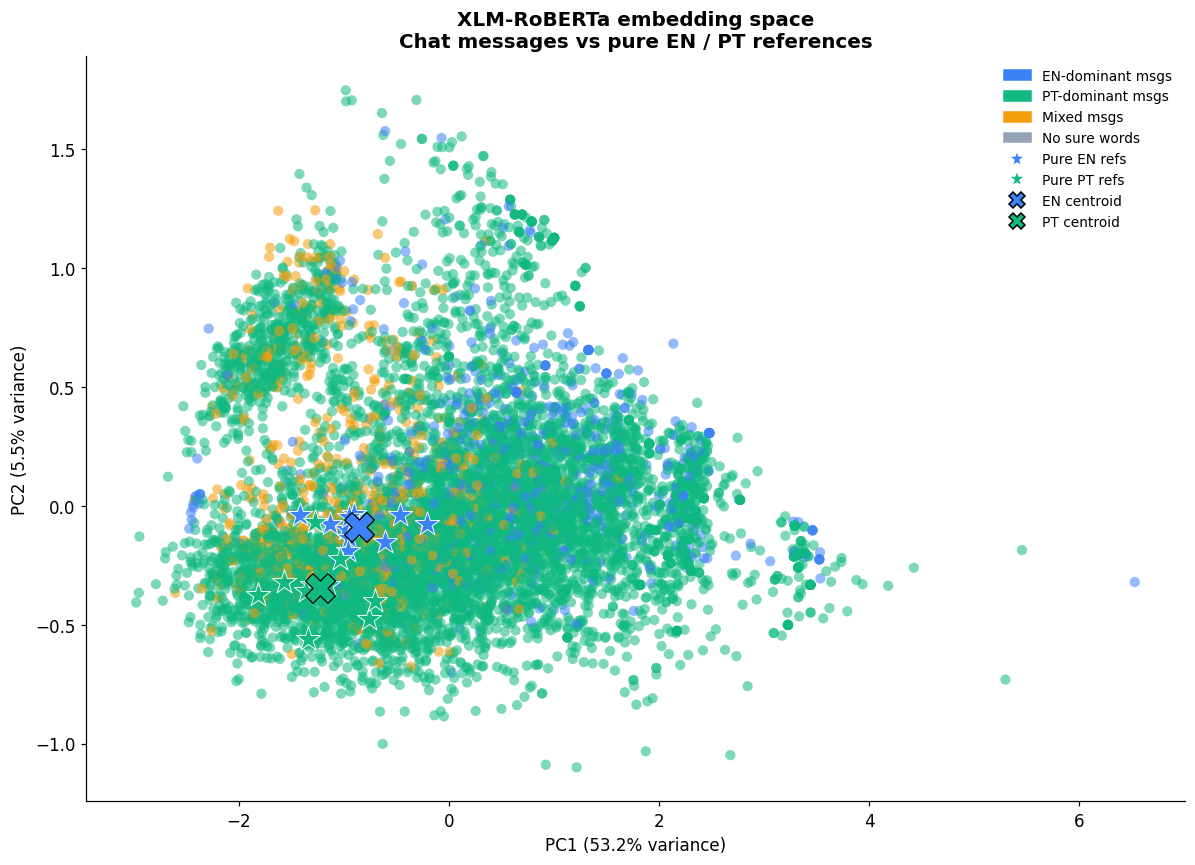

In [26]:
all_vecs  = np.vstack([chat_vecs, en_ref_vecs, pt_ref_vecs])
pca       = PCA(n_components=2, random_state=42)
all_2d    = pca.fit_transform(all_vecs)
var       = pca.explained_variance_ratio_

n_chat    = len(chat_vecs)
n_en_ref  = len(REF_EN)
chat_2d   = all_2d[:n_chat]
en_ref_2d = all_2d[n_chat:n_chat+n_en_ref]
pt_ref_2d = all_2d[n_chat+n_en_ref:]

def msg_color(row):
    if row['is_mixed']:              return C['mixed']
    if row['n_sure'] == 0:           return C['grey']
    return C['en'] if row['en_ratio'] >= 0.5 else C['pt']

point_colors = [msg_color(df_emb.iloc[i]) for i in range(n_chat)]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('white')
ax.scatter(chat_2d[:,0], chat_2d[:,1], c=point_colors,
           alpha=0.55, s=45, edgecolors='none', zorder=2)
ax.scatter(en_ref_2d[:,0], en_ref_2d[:,1], marker='*', s=280,
           color=C['en'], edgecolors='white', lw=0.6, zorder=4)
ax.scatter(pt_ref_2d[:,0], pt_ref_2d[:,1], marker='*', s=280,
           color=C['pt'], edgecolors='white', lw=0.6, zorder=4)
ax.scatter(*en_ref_2d.mean(axis=0), marker='X', s=380,
           color=C['en'], edgecolors='black', lw=0.8, zorder=5)
ax.scatter(*pt_ref_2d.mean(axis=0), marker='X', s=380,
           color=C['pt'], edgecolors='black', lw=0.8, zorder=5)

patches = [
    mpatches.Patch(color=C['en'],    label='EN-dominant msgs'),
    mpatches.Patch(color=C['pt'],    label='PT-dominant msgs'),
    mpatches.Patch(color=C['mixed'], label='Mixed msgs'),
    mpatches.Patch(color=C['grey'],  label='No sure words'),
    plt.Line2D([0],[0],marker='*',color='w',markerfacecolor=C['en'],markersize=12,label='Pure EN refs'),
    plt.Line2D([0],[0],marker='*',color='w',markerfacecolor=C['pt'],markersize=12,label='Pure PT refs'),
    plt.Line2D([0],[0],marker='X',color='w',markerfacecolor=C['en'],markersize=10,
               markeredgecolor='black',label='EN centroid'),
    plt.Line2D([0],[0],marker='X',color='w',markerfacecolor=C['pt'],markersize=10,
               markeredgecolor='black',label='PT centroid'),
]
ax.legend(handles=patches, frameon=False, fontsize=9)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)')
ax.set_title('XLM-RoBERTa embedding space\nChat messages vs pure EN / PT references',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_embedding_space.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


Avg similarity to EN centroid: 0.9924
Avg similarity to PT centroid: 0.9927

Language pull per sender (+ = EN-pulled, - = PT-pulled):
sender
Esther Padrão    0.0001
Gisele          -0.0003
Bruna           -0.0007


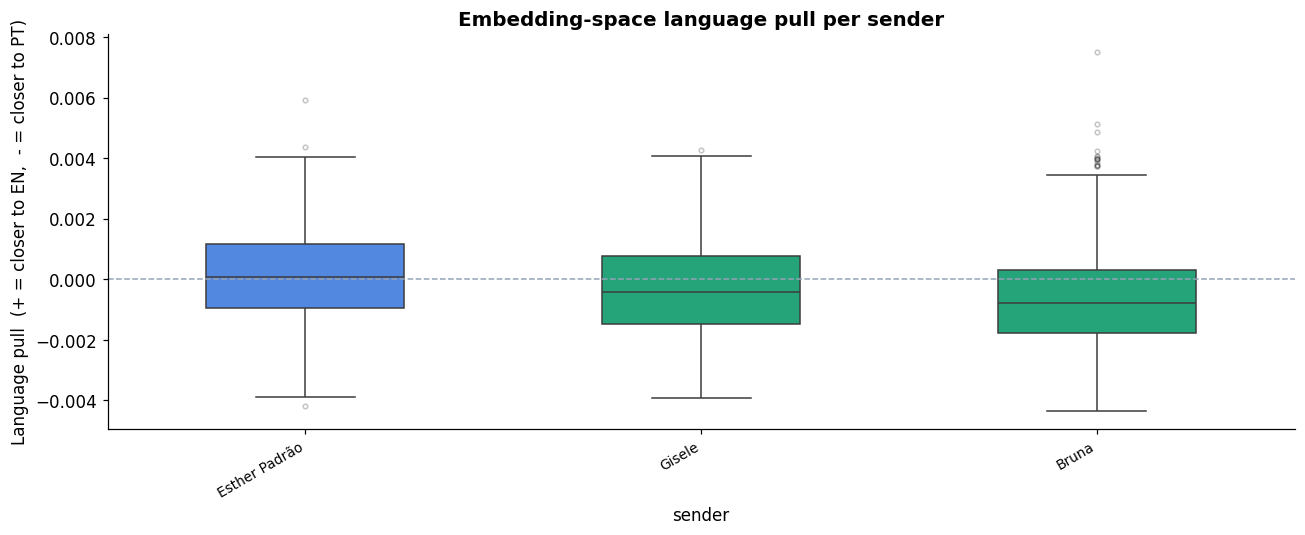

In [27]:
en_centroid = en_ref_vecs.mean(axis=0, keepdims=True)
pt_centroid = pt_ref_vecs.mean(axis=0, keepdims=True)
df_emb['sim_en']    = cosine_similarity(chat_vecs, en_centroid).flatten()
df_emb['sim_pt']    = cosine_similarity(chat_vecs, pt_centroid).flatten()
df_emb['lang_pull'] = df_emb['sim_en'] - df_emb['sim_pt']

print(f'Avg similarity to EN centroid: {df_emb["sim_en"].mean():.4f}')
print(f'Avg similarity to PT centroid: {df_emb["sim_pt"].mean():.4f}')
print()
print('Language pull per sender (+ = EN-pulled, - = PT-pulled):')
print(df_emb.groupby('sender')['lang_pull'].mean()
           .sort_values(ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
sender_order = (df_emb.groupby('sender')['lang_pull']
                .mean().sort_values(ascending=False).index.tolist())
palette = {s: C['en'] if df_emb[df_emb.sender==s]['lang_pull'].mean() > 0
              else C['pt'] for s in sender_order}
sns.boxplot(data=df_emb, x='sender', y='lang_pull',
            order=sender_order, palette=palette, ax=ax,
            width=0.5, flierprops=dict(marker='.', alpha=0.3))
ax.axhline(0, color=C['grey'], linestyle='--', linewidth=1)
ax.set_ylabel('Language pull  (+ = closer to EN,  - = closer to PT)')
ax.set_title('Embedding-space language pull per sender')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_lang_pull.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 10 · Quick summary

In [28]:
print("=== LANGUAGE SPLIT (sure words only) ===")
for sender in df_snd["sender"].tolist():
    grp = df[df["sender"] == sender]
    en  = grp["n_en"].sum()
    pt  = grp["n_pt"].sum()
    total = en + pt
    print(f"{sender:20s}  EN={en:5d} ({en/max(1,total)*100:.1f}%)  "
          f"PT={pt:5d} ({pt/max(1,total)*100:.1f}%)  sure_words={total}")

print("\n=== EN RATIO DISTRIBUTION ===")
df_plot = df[df["n_sure"] >= 3]
print(df_plot.groupby("sender")["en_ratio"].describe().round(3).to_string())

print("\n=== HOW MANY MESSAGES HAVE ANY EN WORDS? ===")
for sender in df_snd["sender"].tolist():
    grp      = df[df["sender"] == sender]
    has_en   = grp["n_en"].gt(0).sum()
    total    = len(grp)
    print(f"{sender:20s}  {has_en}/{total} messages contain ≥1 EN word ({has_en/total*100:.1f}%)")

print("\n=== MIXED MESSAGES ===")
print(f"Total mixed: {df['is_mixed'].sum()} of {len(df)}")
print(df[df["is_mixed"]].groupby("sender").size().to_string())

print("\n=== spaCy EN WORD SAMPLE (first 20 EN words found) ===")
en_sample = []
for _, row in df.iterrows():
    for word, lang, pos, slot in row["pos_labels"]:
        if lang == "en":
            en_sample.append((row["sender"], word, pos, slot))
        if len(en_sample) >= 20: break
    if len(en_sample) >= 20: break
for s, w, p, sl in en_sample:
    print(f"  {s:20s}  '{w}'  POS={p}  slot={sl}")

=== LANGUAGE SPLIT (sure words only) ===
Bruna                 EN=  935 (8.7%)  PT= 9787 (91.3%)  sure_words=10722
Gisele                EN= 2719 (24.0%)  PT= 8622 (76.0%)  sure_words=11341
Esther Padrão         EN=  910 (14.0%)  PT= 5583 (86.0%)  sure_words=6493

=== EN RATIO DISTRIBUTION ===
                count   mean    std  min  25%  50%    75%  max
sender                                                        
Bruna          1729.0  0.080  0.157  0.0  0.0  0.0  0.125  1.0
Esther Padrão   852.0  0.082  0.175  0.0  0.0  0.0  0.000  1.0
Gisele         1351.0  0.079  0.193  0.0  0.0  0.0  0.000  1.0

=== HOW MANY MESSAGES HAVE ANY EN WORDS? ===
Bruna                 697/3634 messages contain ≥1 EN word (19.2%)
Gisele                449/3212 messages contain ≥1 EN word (14.0%)
Esther Padrão         418/2881 messages contain ≥1 EN word (14.5%)

=== MIXED MESSAGES ===
Total mixed: 777 of 9727
sender
Bruna            390
Esther Padrão    178
Gisele           209

=== spaCy EN WORD SAMPL